<a href="https://colab.research.google.com/github/YazGonzalezHerrera/Simulaci-n-II/blob/main/Algoritmo%20Metropolis-Hastings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Simulación mediante el algoritmo Metropolis-Hastings**

El proposito del trabajo es aplicar el método de Metropolis-Hasting mediante simulación para obtener muestras de una distribución de probabilidad bidimensional establecida por una función objetivo: $f(x_1,x_2)$.

Se pretende evaluar la estabilización de diversas cadenas de Markov a partir de condiciones iniciales variadas, además de verificar visualmente que los datos obtenidos por el algoritmo se agrupen en las zonas de mayor densidad de la función objetivo.

Con este fin, se emplearán visualizaciones de las cadenas, un mapa de calor correspondiente a la función objetivo y un gráfico de las muestras generadas durante el proceso.

**Ejercicio**

Se desea simular mediante el algoritmo de Metrópolis-Hastings una distribución de probabilidad bidimensional cuya función de densidad es proporcional a:

$f(x_1,x_2) = Cexp\left[ - \frac{x^2_1x^2_2 + x^2_1 + x^2_2 - 8x_1 - 8x_2}{2}\right]$

Para realizar la simulación se utilizará una distribución propuesta normal, aprovechando que es una distribución simétrica. La propuesta de aceptación se expresa como:

$\alpha (X,Y) = min\left\{1,\frac{\pi (Y)}{\pi (X)}\right\}$

Se generarán diferentes cadenas de Markov a partir de distintos valores iniciales para observar su comportamiento y analizar gráicamente su convergencia hacia la distribución objetivo.

**Solución**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

# Función objetivo

def target(x):

    x1 = x[0]
    x2 = x[1]

    return np.exp(-(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2)

# Metropolis-Hastings

def metropolissampler(niters, x0, sigma):

    # Matriz donde guardaremos x1 y x2
    samples = np.zeros((niters + 1, 2))

    # Punto inicial
    x = np.array(x0, dtype=float)

    samples[0] = x

    aceptadas = 0

    for i in range(niters):

        # Generar candidato Y ~ N(Xt, sigma^2)

        x_p = x + np.random.normal(0, sigma, 2)

        # Calcular probabilidad de aceptación

        fx = target(x)
        fx_p = target(x_p)

        alpha = min(1, fx_p / fx)

        # Generar U ~ Uniforme(0,1)

        u = np.random.uniform()

        # Aceptar o rechazar
        if u < alpha:
            x = x_p
            aceptadas += 1

        # Guardar estado de la cadena
        samples[i + 1] = x

    tasa_aceptacion = aceptadas / niters

    return samples, tasa_aceptacion

# Simulación

niters = 50000
sigma = 0.5

# Tres puntos iniciales
puntos_iniciales = [
    [0.01, 0.01],
    [0.3, 0.3],
    [0.5, 0.5]
]

cadenas = []

for punto in puntos_iniciales:

    cadena, tasa = metropolissampler(
        niters,
        punto,
        sigma
    )

    cadenas.append(cadena)

    print("Punto inicial:", punto, " | Tasa de aceptación:", round(tasa, 4))

Punto inicial: [0.01, 0.01]  | Tasa de aceptación: 0.5192
Punto inicial: [0.3, 0.3]  | Tasa de aceptación: 0.5169
Punto inicial: [0.5, 0.5]  | Tasa de aceptación: 0.5182


**Gráficas de las cadenas de Markov**

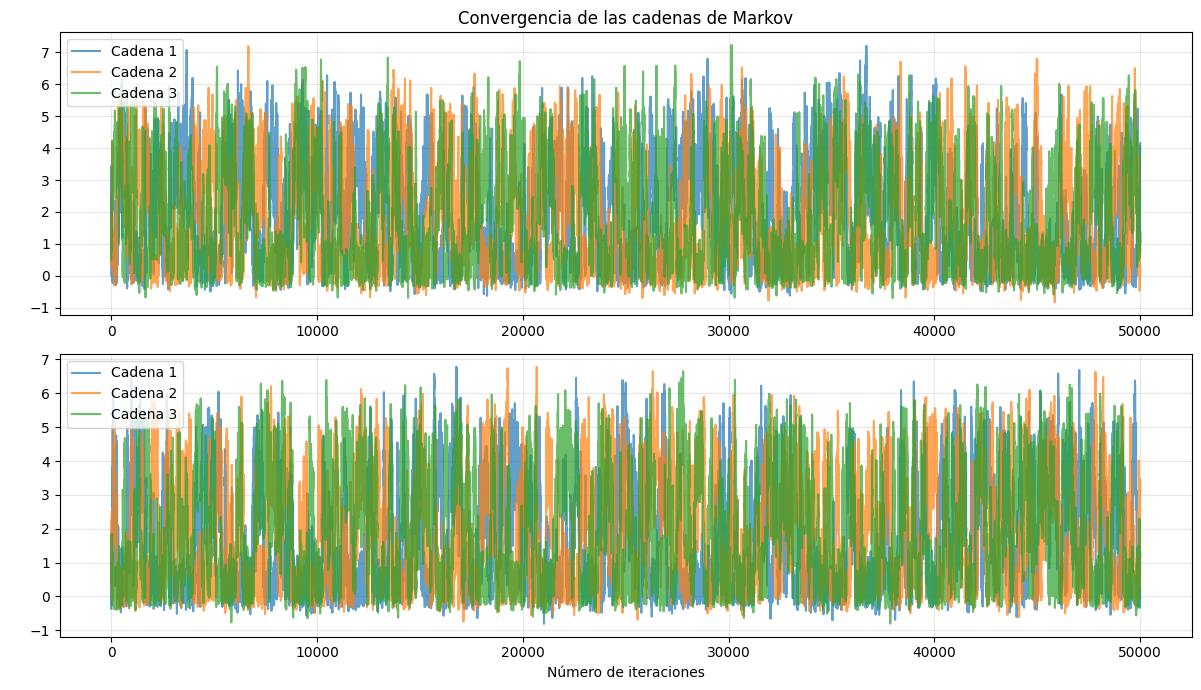

In [7]:
plt.figure(figsize=(12, 7))

for i in range(len(cadenas)):

    plt.subplot(2, 1, 1)
    plt.plot(
        cadenas[i][:, 0],
        alpha=0.7,
        label="Cadena " + str(i + 1)
    )

plt.ylabel(" ")
plt.title("Convergencia de las cadenas de Markov")
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(2, 1, 2)

for i in range(len(cadenas)):

    plt.plot(
        cadenas[i][:, 1],
        alpha=0.7,
        label="Cadena " + str(i + 1)
    )

plt.xlabel("Número de iteraciones")
plt.ylabel(" ")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Muestras Metropolis Hastings sobre el mapa**

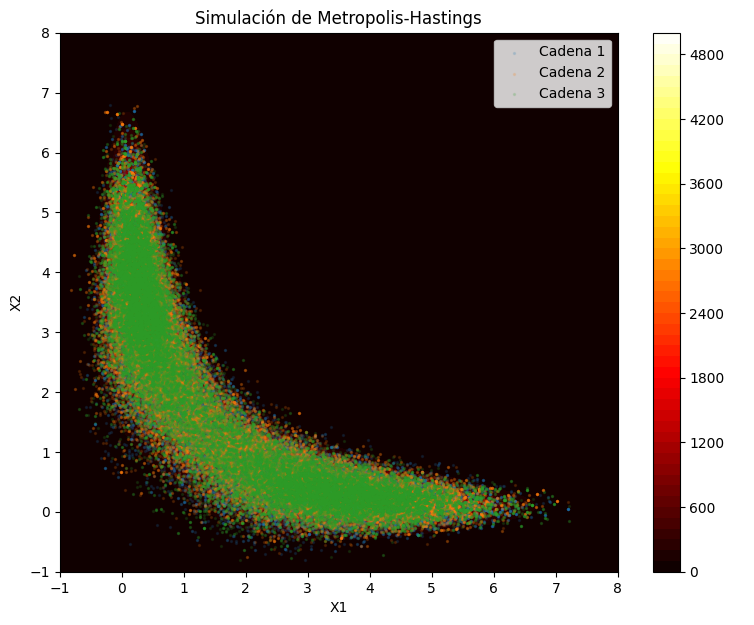

In [16]:
plt.figure(figsize=(9, 7))

# Función objetivo
plt.contourf(
    X1,
    X2,
    Z,
    levels=50,
    cmap="hot"
)

plt.colorbar(label=" ")

# Graficar las muestras
for i in range(len(cadenas)):

    plt.scatter(
        cadenas[i][5000:, 0],
        cadenas[i][5000:, 1],
        s=2,
        alpha=0.15,
        label="Cadena " + str(i + 1)
    )

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Simulación de Metropolis-Hastings")
plt.legend()
plt.show()

**Mapa de calor de la función**

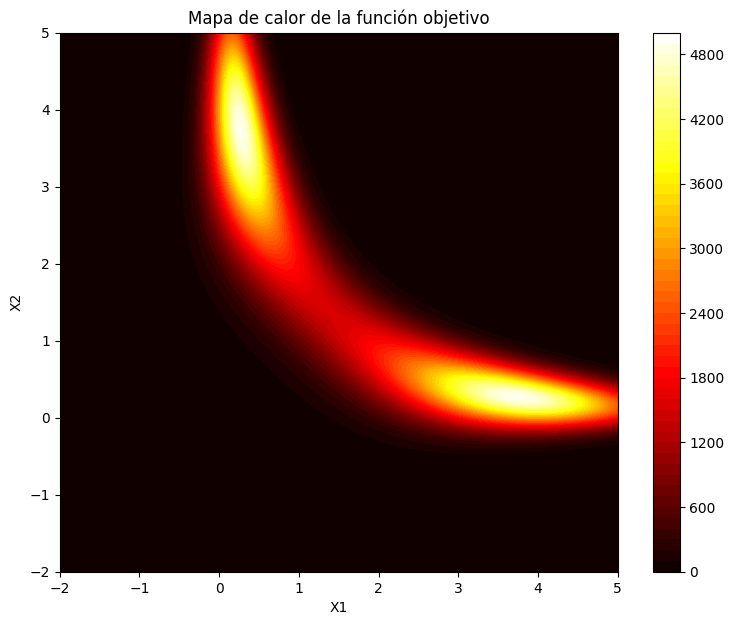

In [18]:
# Malla para graficar la función
x1 = np.linspace(-2, 5, 300)
x2 = np.linspace(-2, 5, 300)

X1, X2 = np.meshgrid(x1, x2)

Z = np.exp(-(X1**2 * X2**2 + X1**2 + X2**2 - 8*X1 - 8*X2) / 2)

# Mapa de calor
plt.figure(figsize=(9, 7))

plt.contourf(
    X1,
    X2,
    Z,
    levels=50,
    cmap="hot"
)

plt.colorbar(label=" ")

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Mapa de calor de la función objetivo")
plt.show()

**Gráfica 3D**

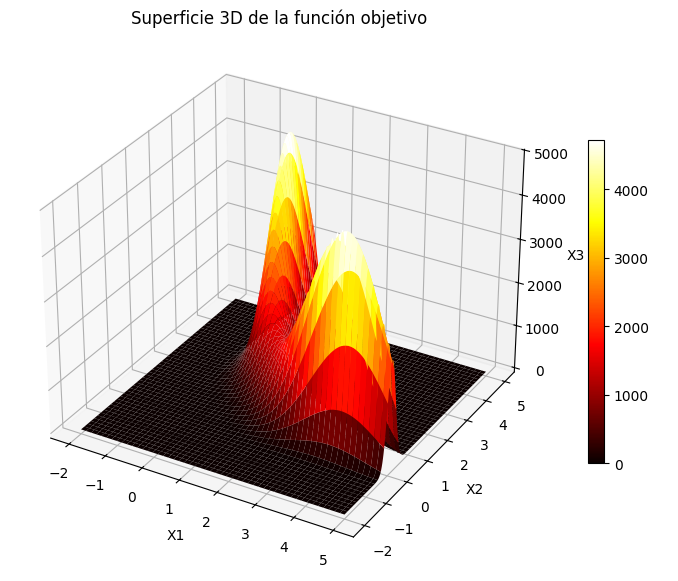

In [20]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

superficie = ax.plot_surface(
    X1,
    X2,
    Z,
    cmap="hot",
    edgecolor="none"
)

fig.colorbar(
    superficie,
    ax=ax,
    shrink=0.6,
    label=" ")

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")

ax.set_title("Superficie 3D de la función objetivo")

plt.show()

**Conclusión**

La simulación sirve para verificar el desempeño del algoritmo de Metropolis-Hastings al muestrear una densidad bidimensional conocida únicamente de manera proporcional. El análisis gráfico de las cadenas de Markov, generadas desde múltiples condiciones iniciales, permitió constatar cómo el procedimiento transita por el espacio hasta priorizar las zonas de mayor probabilidad objetivo. En consecuencia, se confirma experimentalmente la capacidad del algoritmo para abordar distribuciones cuyo muestreo durecto resulta inaccesible o realmente complejo.